In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline import ResearchPipeline
from src.strategies.momentum import MomentumStrategy
from src.transaction_costs import TransactionCostModel

In [3]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [4]:
strategy = MomentumStrategy(
    lookback=13,
    top_n=5,
    bottom_n=5
)

pipeline = ResearchPipeline(
    strategy=strategy
)

In [5]:
results = pipeline.run(prices)

In [6]:
results.keys()

dict_keys(['weekly_returns', 'signals', 'weights', 'strategy_returns', 'cumulative_returns'])

In [7]:
weights = results["weights"]

gross_returns = results["strategy_returns"]

gross_cumulative = results["cumulative_returns"]

In [8]:
cost_model = TransactionCostModel(
    bps=10
)

In [9]:
turnover = cost_model.turnover(
    weights
)

turnover.head()

Date
2000-01-07    0.0
2000-01-14    0.0
2000-01-21    0.0
2000-01-28    0.0
2000-02-04    0.0
Freq: W-FRI, dtype: float64

In [10]:
costs = cost_model.transaction_cost(
    weights
)

costs.head()

Date
2000-01-07    0.0
2000-01-14    0.0
2000-01-21    0.0
2000-01-28    0.0
2000-02-04    0.0
Freq: W-FRI, dtype: float64

In [11]:
net_returns = cost_model.net_returns(
    gross_returns,
    weights
)

net_returns.head()

Date
2000-01-07    0.0
2000-01-14    0.0
2000-01-21    0.0
2000-01-28    0.0
2000-02-04    0.0
Freq: W-FRI, dtype: float64

In [12]:
net_cumulative = cost_model.cumulative_returns(
    net_returns
)

net_cumulative.tail()

Date
2026-01-23    0.402613
2026-01-30    0.415635
2026-02-06    0.446022
2026-02-13    0.445365
2026-02-20    0.433875
Freq: W-FRI, dtype: float64

In [13]:
summary = cost_model.summary(
    gross_returns,
    weights
)

summary

Transaction Cost (bps)     10.000000
Average Turnover            0.267754
Maximum Turnover            1.200000
Total Turnover            365.216667
Average Cost                0.000268
Total Cost                  0.365217
Gross Return               -0.372604
Net Return                 -0.566125
dtype: float64

In [14]:
sensitivity = cost_model.cost_sensitivity(
    gross_returns,
    weights
)

sensitivity

,Transaction Cost (bps),Gross Return,Net Return,Total Cost
0,0,-0.372604,-0.372604,0.000000
1,5,-0.372604,-0.478248,0.182608
2,10,-0.372604,-0.566125,0.365217
3,20,-0.372604,-0.700013,0.730433
4,50,-0.372604,-0.900962,1.826083


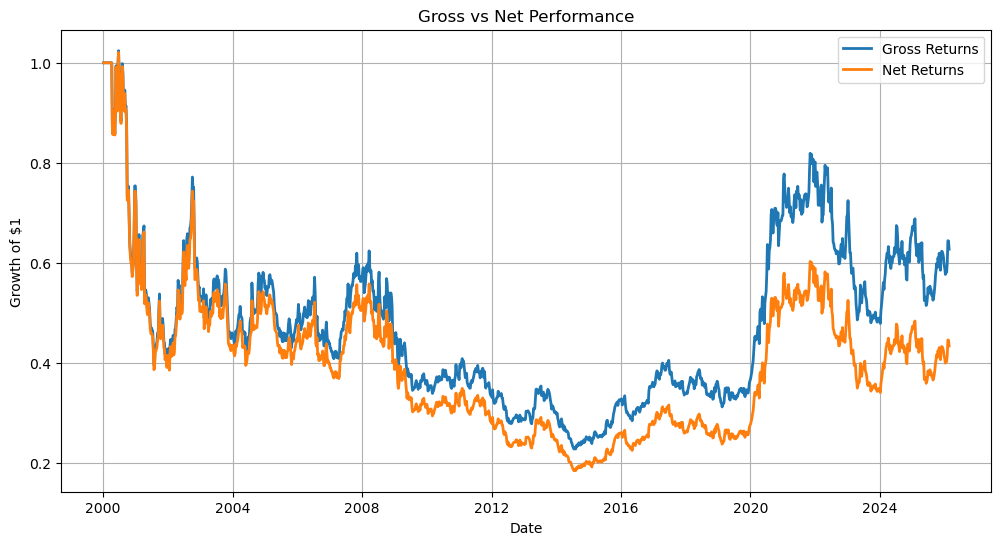

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    gross_cumulative,
    label="Gross Returns",
    linewidth=2
)

plt.plot(
    net_cumulative,
    label="Net Returns",
    linewidth=2
)

plt.title("Gross vs Net Performance")

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.grid(True)
plt.legend()

plt.show()

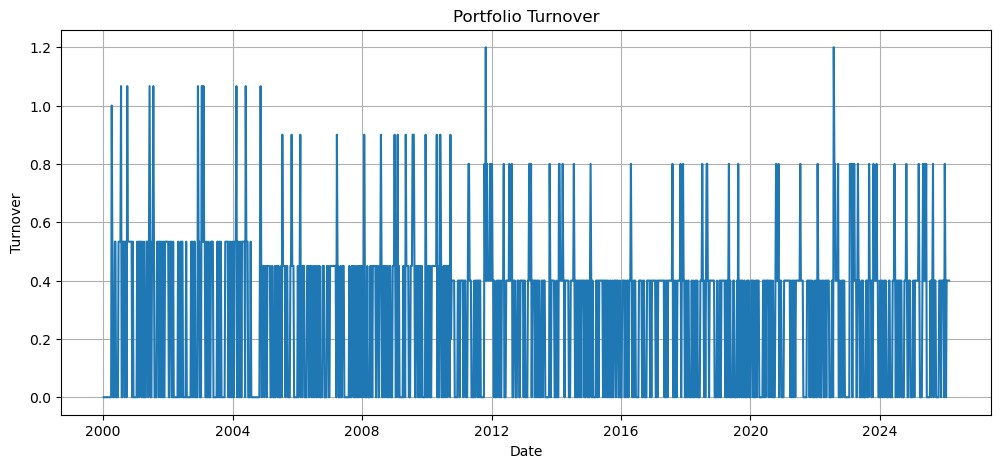

In [16]:
plt.figure(figsize=(12,5))

plt.plot(turnover)

plt.title("Portfolio Turnover")

plt.xlabel("Date")
plt.ylabel("Turnover")

plt.grid(True)

plt.show()

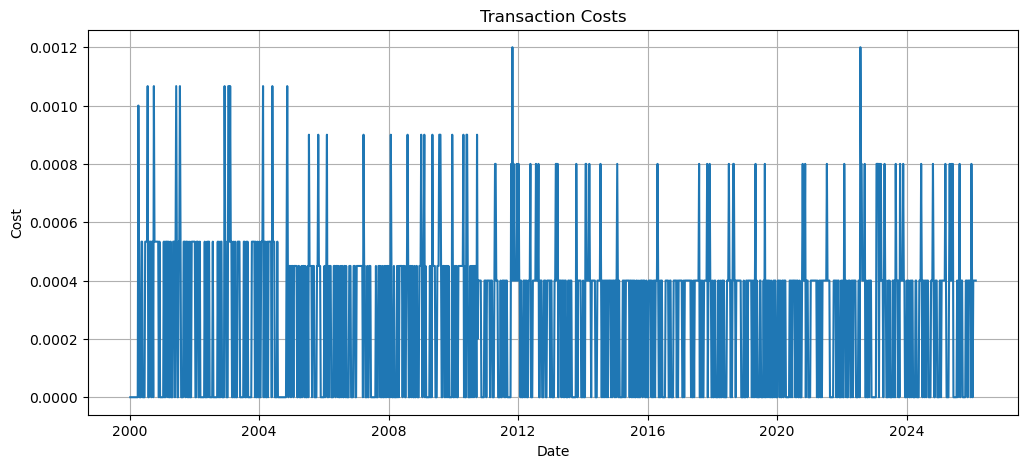

In [17]:
plt.figure(figsize=(12,5))

plt.plot(costs)

plt.title("Transaction Costs")

plt.xlabel("Date")
plt.ylabel("Cost")

plt.grid(True)

plt.show()

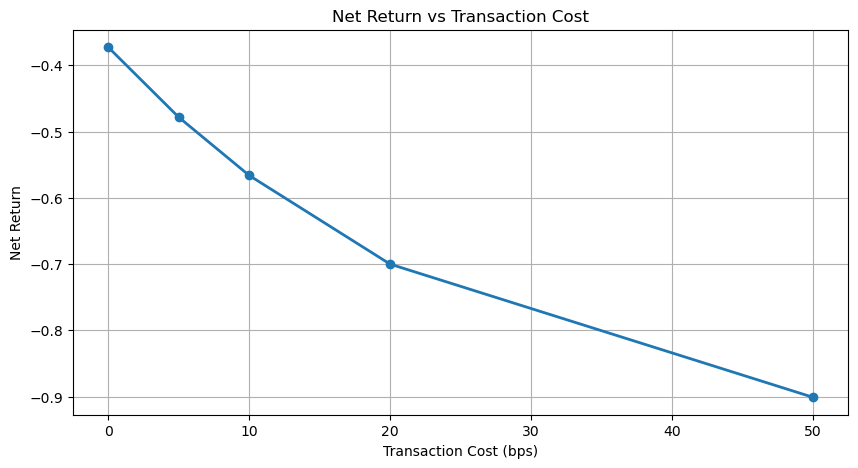

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    sensitivity["Transaction Cost (bps)"],
    sensitivity["Net Return"],
    marker="o",
    linewidth=2
)

plt.title("Net Return vs Transaction Cost")

plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Net Return")

plt.grid(True)

plt.show()

In [19]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

summary.to_csv(
    results_dir / "transaction_cost_summary.csv"
)

sensitivity.to_csv(
    results_dir / "transaction_cost_sensitivity.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


# Findings

## Objective

Evaluate the impact of transaction costs on the momentum strategy.

## Observations

- Portfolio turnover directly drives transaction costs.
- Net returns decline as transaction costs increase.
- Higher trading frequency leads to greater implementation costs.
- Cost sensitivity analysis demonstrates the robustness of the strategy under different market assumptions.

## Conclusion

Including transaction costs produces a more realistic assessment of strategy performance and highlights the importance of efficient portfolio rebalancing.